# P1-DECONFOUND — Extractor-strength × density persistence matrix for a CLUTRR knockoff⁺ FDR gate

This demo reproduces the **analysis core** of the *P1-DECONFOUND* experiment, which de-confounds an
earlier disconfirmation of a **label-free decoy-competition (knockoff⁺) FDR gate**. The gate admits
LLM-extracted kinship facts into a symbolic layer only if each *real* fact beats a property-matched
**counterfactual decoy** by enough margin to certify a target false-discovery rate (FDR).

**The neuro-symbolic pipeline it gates.** An LLM extracts atomic + multi-hop kinship facts from a
short CLUTRR story; before those facts enter a symbolic (Prolog-style) reasoning layer, the gate
filters out likely hallucinations. The knockoff⁺ construction (Barber–Candès 2015) gives a
*distribution-free, label-free* FDR guarantee — **if** the decoy is exchangeable with a genuine error.

**The question this experiment answers.** Iteration-3 found the gate *failed* (anti-conservative) with a
**weak extractor** (`gpt-4.1-nano`). Was that a property of the weak extractor, or of the LLM
self-consistency *scoring* boundary itself? This is a controlled **2-axis factorial**:

| Axis | Levels |
|------|--------|
| **A — extractor strength** | `gpt-4.1-mini` (competent, mh-acc ≈ 0.45) vs `gpt-4.1-nano` (weak, ≈ 0.20) |
| **B — false-positive density** | post-hoc subsample of the scored pool to ~20% / 50% / 85% genuine-FALSE (+ native) |
| family | `multi_hop` (headline) · `atomic` (contrast) |

The extractor is also the **scorer** and the **decoy generator** — a faithful *self-detecting* gate.

**What runs here.** All LLM scoring was done in the full run (cost \$2.94). This demo loads the
**cached per-fact scores** (real score `zᵢ`, decoy score `z̃ᵢ`, signed-max statistic `Wᵢ`, raw
confidence, crisp gold label, density memberships) and recomputes, with **zero API calls**, the
statistical readouts that drive the verdict:

1. the **realized-FDR-vs-α diagonal** (gate's self-reported `decoy_fdr_hat` vs gold-realized FDR) with document-block bootstrap CIs, alongside a **plain raw-confidence baseline** (the purely-neural foil);
2. the **paired win-rate over FALSE pairs** — the KEY readout: < 0.5 means false reals beat their *own* decoys ⇒ the knockoff null is violated ⇒ anti-conservative;
3. the **marginal crux** (is the decoy distributed like a spontaneous error?);
4. the **persistence matrix** across (extractor × density × family), compared to the full-run reference.

The statistical primitives (`fdr_stats` / `fdr_core`) and the `compute_diagonal` / `compute_marginal`
logic are reused **verbatim** from the experiment; only the data plumbing is adapted to read the
cached example records instead of the full run's checkpoints.

In [1]:
# --- Install dependencies (works on Colab and locally) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / scipy / matplotlib are pre-installed on Colab. Installing them on Colab would corrupt
# the pre-loaded C extensions, so install ONLY locally, at Colab's exact versions, so a local
# run mirrors the Colab environment.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
# --- Imports (original analysis modules need only numpy + scipy; matplotlib for the demo figures) ---
import json, os, math, hashlib, types, warnings
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# the original script silences these scipy small-sample warnings; keep the demo output clean
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*midrank.*")
warnings.filterwarnings("ignore", message=".*p-value capped.*")

In [3]:
# --- Load the curated demo data (GitHub URL, with local fallback for offline use) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-4/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("dataset:", data["dataset"])
print("n examples:", len(data["examples"]))
print("full-run verdict:", data["reference"]["headline_verdict"])
ex0 = data["examples"][0]
print("\nexample[0] fields:", list(ex0.keys()))

dataset: CLUTRR-v1-CrispGold-CalibrationAnchor
n examples: 100
full-run verdict: EARNED

example[0] fields: ['input', 'output', 'metadata_extractor', 'metadata_doc_id', 'metadata_fact_type', 'metadata_chain_length_k', 'metadata_z_real_norm', 'metadata_z_decoy_norm', 'metadata_z_real_raw_conf', 'metadata_w_signed_max', 'metadata_density_membership', 'predict_admit_a05', 'predict_admit_a10', 'predict_admit_a20', 'predict_admit_a30', 'predict_admit_a50']


## Configuration

All tunable parameters live here. Because this stage is **pure-CPU re-analysis of cached scores**
(no API, no LLM), it runs in a few seconds even at the full-run statistical settings — so we use the
**full-run α-grid and bootstrap depth verbatim**, and only the *data* is subsampled (≤100 cached
examples). To run faster still on a tiny machine, drop `B_BOOT`/`B_PAIR` (e.g. to 300) or shorten
`ALPHA_GRID`/`DENSITIES`; to reproduce the powered result, point `load_data()` at the full
`method_out.json` instead of the curated subset.

In [5]:
# ---------------------------------------------------------------------------
# Constants / hyperparameters  (verbatim full-run values; cheap because it is pure re-analysis)
# ---------------------------------------------------------------------------
SEED = 20240617

# alpha grid for the realized-FDR-vs-alpha diagonal (k-floors = ceil(1/alpha) = {20,10,5,4,2})
ALPHA_GRID = [0.05, 0.10, 0.20, 0.30, 0.50]   # full run; for a faster demo use e.g. [0.20, 0.50]

# document-block (cluster) bootstrap repetitions
B_BOOT = 2000                             # diagonal realized-FDR CI (full run; faster demo: 300)
B_PAIR = 1000                             # paired win-rate CI       (full run; faster demo: 300)

TAU = 0.05                                # self-report tolerance band
N_FALSE_MIN = 40                          # false-admission floor for a disconfirmation assertion

# Axis A (extractor strength) x family x Axis B (false-positive density)
EXTRACTORS = ["openai/gpt-4.1-mini", "openai/gpt-4.1-nano"]   # competent vs weak
FAMILIES   = ["multi_hop", "atomic"]                          # multi_hop = headline; atomic = contrast
# 'native' = full per-(extractor,family) pool; numeric = density-subsampled cells (Axis B)
DENSITIES  = ["native", 0.20, 0.50, 0.85]                    # full run densities: [0.20, 0.50, 0.85]

# crisp gold labels
TRUE, FALSE, UND = "TRUE", "FALSE", "UNDECIDABLE"

# the cell we walk through in detail (the EARNED headline cell)
HEADLINE = ("openai/gpt-4.1-mini", "multi_hop", 0.85)

## Statistical primitives (`fdr_stats` / `fdr_core`)

These pure, API-free functions are **copied verbatim** from the experiment's `fdr_stats.py` and
`fdr_core.py`. They implement the canonical knockoff statistic, the knockoff⁺ threshold
(Barber–Candès eq. 1.9, with the `+1` that gives *exact* FDR control), the tail-conditioned
win-rate, the document-block bootstrap, Benjamini–Hochberg, two-sample tests and effect sizes, and
the plain raw-confidence baseline gate. We expose them under the same `st` / `fc` names the original
analysis code uses, so the `compute_diagonal` / `compute_marginal` cells below are unchanged.

In [6]:
# --- fdr_stats.py primitives (verbatim) ---------------------------------------
def _jitter(cand_id: str, seed: int) -> float:
    """Tiny deterministic jitter in [0, 1e-6) to break exact ties before ranking."""
    h = hashlib.sha256(f"{cand_id}|{seed}".encode()).hexdigest()
    return (int(h[:12], 16) / float(16**12)) * 1e-6


def rank_normalize(scores: dict, seed: int) -> dict:
    """Map a pool of candidate scores to [0,1] ranks. cand_id->normalized rank."""
    ids = list(scores.keys())
    n = len(ids)
    if n == 0:
        return {}
    if n == 1:
        return {ids[0]: 0.5}
    jittered = np.array([scores[i] + _jitter(i, seed) for i in ids])
    order = np.argsort(jittered, kind="mergesort")
    ranks = np.empty(n, dtype=float)
    ranks[order] = np.arange(n, dtype=float)
    norm = ranks / (n - 1)  # 0 .. 1
    return {ids[i]: float(norm[i]) for i in range(n)}


def W_signed_max(z_real: float, z_decoy: float) -> float:
    """Signed-max statistic: magnitude = max(real, decoy), sign positive iff real beats decoy."""
    mag = max(z_real, z_decoy)
    s = z_real - z_decoy
    sign = 0.0 if s == 0 else math.copysign(1.0, s)
    return mag * sign


def knockoff_plus_threshold(W, alpha: float):
    """knockoff+ operative cutoff T(alpha) (Barber-Candes 2015, eq 1.9):
        T = min{ t in |W| : (1 + #{W_i <= -t}) / max(1, #{W_i >= t}) <= alpha }
    Returns (T, n_admitted, realized_ratio). If no feasible cutoff: (inf, 0, 1.0)."""
    Wa = np.asarray([w for w in W], dtype=float)
    if Wa.size == 0:
        return math.inf, 0, 1.0
    cands = sorted({abs(w) for w in Wa if w != 0.0})
    best = (math.inf, 0, 1.0)
    for t in cands:
        if t <= 0:
            continue
        pos = int(np.sum(Wa >= t))
        neg = int(np.sum(Wa <= -t))
        ratio = (1 + neg) / max(1, pos)
        if ratio <= alpha:
            return float(t), pos, float(ratio)
    return best


def k_floor(alpha: float) -> int:
    """Minimum admissions needed to certify FDR<=alpha (k >= ceil(1/alpha))."""
    return int(math.ceil(1.0 / alpha))


def tail_win_rate(pairs, threshold: float):
    """Among pairs (z_real, z_decoy) with max(z_real,z_decoy) >= T, fraction where the
    decoy beats the real. Target ~0.5 under exchangeability. Returns (win_rate, n_tail)."""
    tail = [(zr, zd) for (zr, zd) in pairs if max(zr, zd) >= threshold]
    if not tail:
        return float("nan"), 0
    wins = sum(1 for (zr, zd) in tail if zd > zr)
    return wins / len(tail), len(tail)


def ks_two_sample(decoy, real, alternative: str = "two-sided"):
    """KS two-sample. Returns (stat, p). Empty input -> (nan, 1.0)."""
    d = np.asarray(decoy, float)
    r = np.asarray(real, float)
    if d.size == 0 or r.size == 0:
        return float("nan"), 1.0
    try:
        res = stats.ks_2samp(d, r, alternative=alternative, method="auto")
        return float(res.statistic), float(res.pvalue)
    except Exception:
        return float("nan"), 1.0


def mannwhitney(decoy, real, alternative: str = "two-sided"):
    """Mann-Whitney U (one- or two-sided). Returns (stat, p)."""
    d = np.asarray(decoy, float)
    r = np.asarray(real, float)
    if d.size == 0 or r.size == 0:
        return float("nan"), 1.0
    try:
        res = stats.mannwhitneyu(d, r, alternative=alternative)
        return float(res.statistic), float(res.pvalue)
    except ValueError:
        return float("nan"), 1.0


def cliffs_delta(a, b) -> float:
    """Cliff's delta in [-1,1]: P(a>b)-P(a<b). Sign(+) => a stochastically larger."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size == 0 or b.size == 0:
        return float("nan")
    b_sorted = np.sort(b)
    gt = np.searchsorted(b_sorted, a, side="left").sum()
    lt = (b.size - np.searchsorted(b_sorted, a, side="right")).sum()
    return float((gt - lt) / (a.size * b.size))


def tail_gap(decoy, spont) -> dict:
    """Compare decoy vs spontaneous-error tails. mean_diff>0 => decoys score HIGHER than genuine
    errors (CONSERVATIVE); <0 => decoys score LOWER (false reals beat them => ANTI-CONSERVATIVE)."""
    d = np.asarray(decoy, float)
    s = np.asarray(spont, float)
    ks_sup, _ = ks_two_sample(d, s, "two-sided")
    w1 = float(stats.wasserstein_distance(d, s)) if d.size and s.size else float("nan")
    md = float(d.mean() - s.mean()) if d.size and s.size else float("nan")
    return {"ks_sup": ks_sup, "wasserstein": w1, "mean_diff": md,
            "cliffs_delta": cliffs_delta(d, s), "n_decoy": int(d.size), "n_other": int(s.size)}


def doc_block_bootstrap(doc_units, stat_fn, B: int = 2000, seed: int = 0, ci: float = 0.95) -> dict:
    """Resample whole documents with replacement B times; recompute stat_fn on the pooled resample.
    Returns point estimate, percentile CI, and bootstrap SE."""
    n = len(doc_units)
    point = stat_fn(doc_units)
    if n == 0:
        return {"point": float("nan"), "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": 0}
    rng = np.random.default_rng(seed)
    reps = np.empty(B)
    idx_all = np.arange(n)
    for b in range(B):
        idx = rng.choice(idx_all, size=n, replace=True)
        resample = [doc_units[i] for i in idx]
        reps[b] = stat_fn(resample)
    reps = reps[~np.isnan(reps)]
    if reps.size == 0:
        return {"point": float(point) if point == point else float("nan"),
                "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": n}
    lo = float(np.percentile(reps, 100 * (1 - ci) / 2))
    hi = float(np.percentile(reps, 100 * (1 - (1 - ci) / 2)))
    return {"point": float(point) if point == point else float(np.mean(reps)),
            "ci_low": lo, "ci_high": hi, "se": float(np.std(reps, ddof=1)),
            "B": int(reps.size), "n_docs": n}


def benjamini_hochberg(pvals, q: float = 0.05):
    """BH step-up. Returns list aligned to input order with adjusted p and reject flag."""
    p = np.asarray(pvals, float)
    m = p.size
    if m == 0:
        return []
    order = np.argsort(p, kind="mergesort")
    ranked = p[order]
    adj = np.empty(m)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        val = ranked[i] * m / (i + 1)
        prev = min(prev, val)
        adj[i] = min(prev, 1.0)
    adj_orig = np.empty(m)
    adj_orig[order] = adj
    return [{"raw_p": float(p[i]), "bh_adj_p": float(adj_orig[i]),
             "reject": bool(adj_orig[i] <= q)} for i in range(m)]


def empirical_cdf(values, grid):
    """Empirical CDF of `values` evaluated on a common `grid`."""
    v = np.sort(np.asarray(values, float))
    g = np.asarray(grid, float)
    if v.size == 0:
        return [float("nan")] * len(g)
    cdf = np.searchsorted(v, g, side="right") / v.size
    return [float(x) for x in cdf]

In [7]:
# --- fdr_core.py: the plain raw-confidence baseline gate (verbatim) ----------
def plain_threshold_gate(Z, alpha: float):
    """Decoy-free label-free baseline: admit the most-confident candidates until the
    *self-estimated* FDR of the admitted set (1 - mean admitted confidence) would exceed alpha.
    This is the standard 'raw LLM confidence' gate the decoy method is compared against.
    Returns (threshold, admitted_indices, est_fdr_of_admitted)."""
    Z = np.asarray(Z, dtype=float)
    n = Z.size
    if n == 0:
        return math.inf, [], 1.0
    order = np.argsort(-Z, kind="stable")  # descending confidence
    zsorted = Z[order]
    cumsum = np.cumsum(zsorted)
    best_k = 0
    best_est = 1.0
    for k in range(1, n + 1):
        est_fdr = 1.0 - cumsum[k - 1] / k  # 1 - mean confidence of the top-k admitted
        if est_fdr <= alpha:
            best_k = k
            best_est = est_fdr
    if best_k == 0:
        return math.inf, [], 1.0
    threshold = float(zsorted[best_k - 1])
    admitted = sorted(int(i) for i in order[:best_k])
    return threshold, admitted, float(best_est)

# expose the primitives under the module aliases the original analysis code uses
st = types.SimpleNamespace(
    W_signed_max=W_signed_max, knockoff_plus_threshold=knockoff_plus_threshold, k_floor=k_floor,
    tail_win_rate=tail_win_rate, ks_two_sample=ks_two_sample, mannwhitney=mannwhitney,
    tail_gap=tail_gap, doc_block_bootstrap=doc_block_bootstrap,
    benjamini_hochberg=benjamini_hochberg, empirical_cdf=empirical_cdf)
fc = types.SimpleNamespace(plain_threshold_gate=plain_threshold_gate)
print("primitives ready:", [k for k in vars(st)], "| fc:", [k for k in vars(fc)])

primitives ready: ['W_signed_max', 'knockoff_plus_threshold', 'k_floor', 'tail_win_rate', 'ks_two_sample', 'mannwhitney', 'tail_gap', 'doc_block_bootstrap', 'benjamini_hochberg', 'empirical_cdf'] | fc: ['plain_threshold_gate']


## Reconstruct the scored-real pool from cached examples

Each example is one **scored real fact**. We flatten them into the per-fact records the analysis
expects: the rank-normalized real score `zr`, the decoy score `zd`, the crisp gold `label`, and the
document id (the bootstrap resamples whole documents). We **recompute** the signed-max statistic
`W = W_signed_max(zr, zd)` from the scores to show the gate's statistic in action, and check it
matches the value cached during the full run.

In [8]:
reals = []
for i, e in enumerate(data["examples"]):
    inp = json.loads(e["input"])
    reals.append({
        "real_id": i,
        "extractor": e["metadata_extractor"],
        "family": e["metadata_fact_type"],
        "doc_id": e["metadata_doc_id"],
        "label": e["output"],                       # crisp gold: TRUE / FALSE
        "zr": e["metadata_z_real_norm"],            # rank-normalized real score
        "zd": e["metadata_z_decoy_norm"],           # rank-normalized counterfactual-decoy score
        "raw_conf": e["metadata_z_real_raw_conf"],  # raw confidence (for the plain baseline)
        "w": W_signed_max(e["metadata_z_real_norm"], e["metadata_z_decoy_norm"]),
        "w_cached": e["metadata_w_signed_max"],
        "densities": e["metadata_density_membership"],
        "claim": inp.get("claim"),
    })

# raw_conf lookup for the plain (decoy-free) baseline gate
raw_conf = {r["real_id"]: r["raw_conf"] for r in reals}

# the recomputed W must match the value cached during the full LLM run
max_dev = max(abs(r["w"] - r["w_cached"]) for r in reals)
print(f"reals reconstructed: {len(reals)}")
print(f"max |W_recomputed - W_cached| = {max_dev:.2e}  (should be ~0)")
print("\nsample record:", {k: reals[0][k] for k in ('extractor','family','label','zr','zd','w','densities')})

reals reconstructed: 100
max |W_recomputed - W_cached| = 0.00e+00  (should be ~0)

sample record: {'extractor': 'openai/gpt-4.1-mini', 'family': 'multi_hop', 'label': 'FALSE', 'zr': 0.642857, 'zd': 0.785714, 'w': -0.785714, 'densities': [0.85]}


## Build per-document pairs for one cell

`build_pairs_from_examples` collects, for a given (extractor, family, density) **cell**, the
per-document list of `{zr, zd, label, w, real_id}` records — exactly the `per_doc` structure the
original `build_pairs` produced from the full run's checkpoints. The density filter uses each real's
precomputed **density membership** (Axis B is a *free* post-hoc subsample of the cached scores;
`'native'` keeps the whole pool).

In [9]:
def build_pairs_from_examples(reals, extractor, family, density):
    """Per-doc list of {zr, zd, label, doc_id, real_id, w} for reals of `family` from `extractor`,
    restricted to the density-subsample membership. Mirrors the original build_pairs(), reading
    cached example scores instead of pipeline checkpoints."""
    per_doc = {}
    for r in reals:
        if r["extractor"] != extractor or r["family"] != family:
            continue
        if density != "native" and density not in r["densities"]:
            continue
        per_doc.setdefault(r["doc_id"], []).append(
            {"zr": r["zr"], "zd": r["zd"], "label": r["label"], "doc_id": r["doc_id"],
             "w": st.W_signed_max(r["zr"], r["zd"]), "real_id": r["real_id"]})
    return per_doc


def _doc_arrays(per_doc):
    out = []
    for v in per_doc.values():
        out.append((np.array([p["zr"] for p in v], float),
                    np.array([p["zd"] for p in v], float),
                    np.array([p["label"] == FALSE for p in v], bool)))
    return out

## Diagonal + paired readout (`compute_diagonal`, verbatim)

This is the heart of the method, **copied verbatim** from the experiment. For each α it computes:

- the knockoff⁺ threshold `T(α)` on the `W` array, the admitted set, and the gate's self-reported
  `decoy_fdr_hat`;
- the **gold-realized FDR** of the admitted set (with a document-block bootstrap CI);
- the **plain raw-confidence baseline** realized FDR (the purely-neural foil).

Then the **paired win-rate over FALSE pairs** at the operative cutoff — the KEY readout. A win-rate
whose CI sits entirely **below 0.5** means false reals beat their *own* counterfactual decoys: the
paired knockoff null is violated and the gate is anti-conservative.

In [10]:
def _nan(x):
    if x is None:
        return None
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return None
    return round(float(x), 6)


# Vectorized knockoff+ for the bootstrap hot loop (IDENTICAL output to st.knockoff_plus_threshold)
def _knockoff_fast(W, alpha: float):
    Wa = np.asarray(W, dtype=float)
    if Wa.size == 0:
        return math.inf, 0, 1.0
    sW = np.sort(Wa)
    mags = np.unique(np.abs(Wa))
    mags = mags[mags > 0.0]
    if mags.size == 0:
        return math.inf, 0, 1.0
    pos = sW.size - np.searchsorted(sW, mags, side="left")
    neg = np.searchsorted(sW, -mags, side="right")
    ratio = (1.0 + neg) / np.maximum(1, pos)
    feas = np.nonzero(ratio <= alpha)[0]
    if feas.size == 0:
        return math.inf, 0, 1.0
    i = int(feas[0])
    return float(mags[i]), int(pos[i]), float(ratio[i])


def _realized_fast(zr, zd, isfalse, alpha: float) -> float:
    if zr.size == 0:
        return float("nan")
    s = np.sign(zr - zd)
    W = np.where(s == 0, 0.0, np.maximum(zr, zd) * s)
    T, _, _ = _knockoff_fast(W, alpha)
    if math.isinf(T):
        return float("nan")
    adm = W >= T
    n = int(adm.sum())
    if n == 0:
        return float("nan")
    return float((isfalse & adm).sum()) / n

In [11]:
def compute_diagonal(per_doc, raw_conf: dict, populable: bool, with_ci: bool = True):
    """Realized-FDR-vs-alpha diagonal (+ doc-block CIs, decoy_fdr_hat, plain baseline) and the
    PAIRED win-rate over FALSE pairs at the operative cutoff. per_doc: {doc_id:[{zr,zd,label,w,real_id}]}.
    raw_conf: real_id -> raw confidence in [0,1] for the plain (decoy-free) baseline gate."""
    flat = [p for v in per_doc.values() for p in v]
    doc_arrays = _doc_arrays(per_doc)
    n_false_total = sum(1 for p in flat if p["label"] == FALSE)
    n_true_total = sum(1 for p in flat if p["label"] == TRUE)

    rows = []
    for alpha in ALPHA_GRID:
        W = [p["w"] for p in flat]
        T, n_adm_pos, ratio = st.knockoff_plus_threshold(W, alpha)
        if math.isinf(T):
            realized, n_adm, n_false, dfh = float("nan"), 0, 0, None
        else:
            adm = [p for p in flat if p["w"] >= T]
            n_adm = len(adm)
            n_false = sum(1 for p in adm if p["label"] == FALSE)
            realized = (n_false / n_adm) if n_adm else float("nan")
            dfh = ratio
        ci = {"ci_low": None, "ci_high": None}
        if with_ci and flat:
            def stat_fn(resample, a=alpha):
                if not resample:
                    return float("nan")
                zr = np.concatenate([u[0] for u in resample])
                zd = np.concatenate([u[1] for u in resample])
                isf = np.concatenate([u[2] for u in resample])
                return _realized_fast(zr, zd, isf, a)
            cib = st.doc_block_bootstrap(doc_arrays, stat_fn, B=B_BOOT, seed=SEED)
            ci = {"ci_low": cib["ci_low"], "ci_high": cib["ci_high"]}
        # PLAIN raw-confidence baseline gate (decoy-free purely-neural foil)
        labelled = [p for p in flat if p["real_id"] in raw_conf]
        Zraw = [raw_conf[p["real_id"]] for p in labelled]
        labraw = [p["label"] for p in labelled]
        _, adm_p, est_p = fc.plain_threshold_gate(Zraw, alpha)
        nfp = sum(1 for i in adm_p if labraw[i] == FALSE)
        realized_p = (nfp / len(adm_p)) if adm_p else float("nan")

        self_report_anti = (dfh is not None and not math.isnan(realized)
                            and (realized - dfh) > TAU)
        certified = n_adm >= st.k_floor(alpha)
        rows.append({
            "target_alpha": alpha, "decoy_fdr_hat": _nan(dfh), "realized_fdr": _nan(realized),
            "triple_alpha_decoyfdrhat_realized": [alpha, _nan(dfh), _nan(realized)],
            "ci_low": _nan(ci["ci_low"]), "ci_high": _nan(ci["ci_high"]),
            "n_admitted": n_adm, "n_false_admitted": n_false, "k_floor": st.k_floor(alpha),
            "certified": bool(certified), "self_report_anti_conservative": bool(self_report_anti),
            "plain_realized_fdr": _nan(realized_p), "plain_n_admitted": len(adm_p),
            "plain_est_fdr": _nan(est_p)})

    certified_alphas = [r["target_alpha"] for r in rows if r["certified"]]
    alpha_star = max(certified_alphas) if certified_alphas else None  # most permissive certified

    # PAIRED-EXCHANGEABILITY over FALSE-real pairs in the operative admission tail (KEY readout)
    Tcut, _, _ = st.knockoff_plus_threshold([p["w"] for p in flat], 0.50)
    cutv = Tcut if not math.isinf(Tcut) else 0.0
    fp = [p for p in flat if p["label"] == FALSE]
    wr_pe, n_tail = st.tail_win_rate([(p["zr"], p["zd"]) for p in fp], cutv)
    tail = [p for p in fp if max(p["zr"], p["zd"]) >= cutv]
    ks_s, ks_p = st.ks_two_sample([p["zd"] for p in tail], [p["zr"] for p in tail], "two-sided")
    fb = {}
    for p in tail:
        fb.setdefault(p["doc_id"], []).append(p)

    def _wrfn(resample):
        flatp = [p for grp in resample for p in grp]
        if not flatp:
            return float("nan")
        return float(np.mean([1.0 if p["zd"] > p["zr"] else 0.0 for p in flatp]))
    ci_pe = (st.doc_block_bootstrap(list(fb.values()), _wrfn, B=B_PAIR, seed=SEED)
             if with_ci and fb else {"ci_low": None, "ci_high": None})
    lo, hi = ci_pe["ci_low"], ci_pe["ci_high"]
    paired_fails = bool(hi is not None and not math.isnan(hi) and hi < 0.5)
    paired_ok = bool(lo is not None and hi is not None and not math.isnan(lo)
                     and lo <= 0.5 <= hi)
    paired = {"operative_alpha": 0.50, "win_rate_false_pairs": _nan(wr_pe), "n_tail": n_tail,
              "win_rate_ci": [_nan(lo), _nan(hi)], "ks_p_decoy_vs_real": ks_p,
              "paired_fails": paired_fails, "paired_ok": paired_ok,
              "interpretation": ("win-rate ~0.5 (CI covers 0.5) => paired-exchangeable knockoff null; "
                                 "CI_high<0.5 => false reals beat their own decoys (anti-conservative)")}
    return {"rows": rows, "alpha_star": alpha_star, "n_pairs": len(flat),
            "n_false_total": n_false_total, "n_true_total": n_true_total, "paired": paired}

## Marginal crux (`compute_marginal`, verbatim body)

The marginal view asks whether the counterfactual **decoy** is distributed like a genuine
**spontaneous error** (FALSE real) — and is separable from a **true positive**. If the decoy tail
mean sits *below* the spontaneous-error tail (`gap_mean_diff < 0`), the decoy is *too easy*: the
model rates its own (possibly wrong) extraction above the decoy. That is the same self-favoring bias
the paired win-rate detects, seen marginally. The statistical body is **copied verbatim** from the
experiment; only the population-building is adapted to the cached records.

In [12]:
def compute_marginal_from_examples(reals, extractor, family, density):
    """Decoy ~ spontaneous-error (and decoy != true-positive) crux for one cell. Builds the three
    score populations from the cached records, then runs the original compute_marginal body."""
    F_tp, F_sp, F_dc = [], [], []   # true-positive reals, spontaneous-error (FALSE) reals, decoys
    for r in reals:
        if r["extractor"] != extractor or r["family"] != family:
            continue
        if density != "native" and density not in r["densities"]:
            continue
        z = r["zr"]
        if r["label"] == TRUE:
            F_tp.append(z)
        elif r["label"] == FALSE:
            F_sp.append(z)
        F_dc.append(r["zd"])
    # ---- verbatim from the original compute_marginal ----
    pooled = np.array(F_tp + F_sp + F_dc)
    out = {}
    for rname, q in {"full": None, "tail_top50pct": 0.50}.items():
        if q is None:
            dec, spo, tru = F_dc, F_sp, F_tp
        else:
            thr = float(np.quantile(pooled, q)) if pooled.size else 0.0
            dec = [z for z in F_dc if z >= thr]
            spo = [z for z in F_sp if z >= thr]
            tru = [z for z in F_tp if z >= thr]
        ks_ms, ks_mp = st.ks_two_sample(dec, spo, "two-sided")
        mw_ms, mw_mp = st.mannwhitney(dec, spo, "two-sided")
        ks_ds, ks_dp = st.ks_two_sample(dec, tru, "two-sided")
        mw_ds, mw_dp = st.mannwhitney(dec, tru, "two-sided")
        gap = st.tail_gap(dec, spo)
        match_ok = (ks_mp > 0.05) and (mw_mp > 0.05)
        differ_ok = (ks_dp <= 0.05) or (mw_dp <= 0.05)
        verdict = ("VALID" if (match_ok and differ_ok)
                   else ("GAP:decoys_too_hard(conservative)" if gap["mean_diff"] > 0
                         else "GAP:decoys_too_easy(anti-conservative)"))
        out[rname] = {"n_decoy": len(dec), "n_spont": len(spo), "n_truepos": len(tru),
                      "decoy_vs_spont": {"ks_p": ks_mp, "mw_p": mw_mp},
                      "decoy_vs_truepos": {"ks_p": ks_dp, "mw_p": mw_dp},
                      "gap_mean_diff": _nan(gap["mean_diff"]), "verdict": verdict}
    tail = out["tail_top50pct"]
    marginal_holds = bool(tail["decoy_vs_spont"]["ks_p"] > 0.05
                          and tail["decoy_vs_spont"]["mw_p"] > 0.05
                          and ((tail["decoy_vs_truepos"]["ks_p"] <= 0.05)
                               or (tail["decoy_vs_truepos"]["mw_p"] <= 0.05)))
    gap_md = tail["gap_mean_diff"]
    marginal_decoy_not_too_easy = bool(gap_md is not None and gap_md >= -0.05)
    marginal_direction = ("too_easy_anti_conservative" if (gap_md is not None and gap_md < -1e-9)
                          else ("too_hard_conservative" if (gap_md is not None and gap_md > 1e-9)
                                else "balanced"))
    return {"regions": out, "marginal_holds": marginal_holds,
            "marginal_decoy_not_too_easy": marginal_decoy_not_too_easy,
            "marginal_direction": marginal_direction, "tail_gap_mean_diff": gap_md,
            "n_truepos": len(F_tp), "n_spont": len(F_sp), "n_decoy": len(F_dc),
            "cdf": {"x": [round(x, 3) for x in np.linspace(0, 1, 51)],
                    "cdf_truepos": st.empirical_cdf(F_tp, np.linspace(0, 1, 51)),
                    "cdf_spont": st.empirical_cdf(F_sp, np.linspace(0, 1, 51)),
                    "cdf_decoy": st.empirical_cdf(F_dc, np.linspace(0, 1, 51))}}

## Walk through the headline cell

The EARNED headline cell is **`gpt-4.1-mini × multi_hop × density 0.85`**: a *competent* extractor at
high false-positive density. We compute its diagonal, paired readout, and marginal crux in detail.

In [13]:
ext, fam, dens = HEADLINE
per_doc = build_pairs_from_examples(reals, ext, fam, dens)
flat = [p for v in per_doc.values() for p in v]
n_false = sum(1 for p in flat if p["label"] == FALSE)
n_true  = sum(1 for p in flat if p["label"] == TRUE)
print(f"cell = {ext} x {fam} x density {dens}")
print(f"  docs={len(per_doc)}  pairs={len(flat)}  FALSE={n_false}  TRUE={n_true}\n")

diag = compute_diagonal(per_doc, raw_conf, populable=(n_false >= N_FALSE_MIN), with_ci=True)
print("realized-FDR-vs-alpha diagonal  (decoy gate vs plain raw-confidence baseline):")
print(f"  {'alpha':>6} {'decoy_fdr_hat':>14} {'realized_fdr':>13} {'realized_ci':>20} "
      f"{'n_adm':>6} {'plain_realized':>15}")
for r in diag["rows"]:
    ci = f"[{r['ci_low']}, {r['ci_high']}]"
    print(f"  {r['target_alpha']:>6} {str(r['decoy_fdr_hat']):>14} {str(r['realized_fdr']):>13} "
          f"{ci:>20} {r['n_admitted']:>6} {str(r['plain_realized_fdr']):>15}")

p = diag["paired"]
print(f"\nPAIRED win-rate over FALSE pairs @ operative cutoff: "
      f"{p['win_rate_false_pairs']}  CI={p['win_rate_ci']}  (n_tail={p['n_tail']})")
print(f"  paired_fails (CI_high < 0.5)? {p['paired_fails']}   -> {p['interpretation']}")

marg = compute_marginal_from_examples(reals, ext, fam, dens)
print(f"\nMARGINAL crux: direction={marg['marginal_direction']}  "
      f"tail_gap_mean_diff={marg['tail_gap_mean_diff']}  marginal_holds={marg['marginal_holds']}")

cell = openai/gpt-4.1-mini x multi_hop x density 0.85
  docs=20  pairs=21  FALSE=20  TRUE=1



realized-FDR-vs-alpha diagonal  (decoy gate vs plain raw-confidence baseline):
   alpha  decoy_fdr_hat  realized_fdr          realized_ci  n_adm  plain_realized
    0.05           None          None         [None, None]      0            None
     0.1           None          None      [0.920595, 1.0]      0             1.0
     0.2           None          None      [0.888889, 1.0]      0             1.0
     0.3           0.25           1.0      [0.866667, 1.0]      4             1.0
     0.5            0.5           1.0      [0.823529, 1.0]     10             1.0

PAIRED win-rate over FALSE pairs @ operative cutoff: 0.285714  CI=[0.071429, 0.571429]  (n_tail=14)
  paired_fails (CI_high < 0.5)? False   -> win-rate ~0.5 (CI covers 0.5) => paired-exchangeable knockoff null; CI_high<0.5 => false reals beat their own decoys (anti-conservative)

MARGINAL crux: direction=too_easy_anti_conservative  tail_gap_mean_diff=-0.026253  marginal_holds=False


## The full persistence matrix

Now sweep **every** (extractor × family × density) cell and assemble the persistence matrix: for each
cell we record the operative realized FDR, the gate's self-report, the paired win-rate (the key
readout), and the marginal direction. With the small demo subset some cells are sparse (few FALSE
reals → wide CIs / `None`); the full-run reference (loaded from the same file) is the powered result.

In [14]:
def build_cell(reals, raw_conf, extractor, family, density):
    per_doc = build_pairs_from_examples(reals, extractor, family, density)
    flat = [p for v in per_doc.values() for p in v]
    if not flat:
        return None
    n_false = sum(1 for p in flat if p["label"] == FALSE)
    n_true  = sum(1 for p in flat if p["label"] == TRUE)
    diag = compute_diagonal(per_doc, raw_conf, populable=(n_false >= N_FALSE_MIN), with_ci=True)
    marg = compute_marginal_from_examples(reals, extractor, family, density)
    a = diag["alpha_star"] if diag["alpha_star"] is not None else max(ALPHA_GRID)
    row = next((r for r in diag["rows"] if r["target_alpha"] == a), diag["rows"][-1])
    pd = diag["paired"]
    return {
        "extractor": extractor, "family": family, "density": density,
        "n_pairs": len(flat), "n_false": n_false, "n_true": n_true,
        "alpha_star": diag["alpha_star"],
        "realized_fdr": row["realized_fdr"], "decoy_fdr_hat": row["decoy_fdr_hat"],
        "plain_realized_fdr": row["plain_realized_fdr"],
        "paired_win_rate": pd["win_rate_false_pairs"], "paired_win_rate_ci": pd["win_rate_ci"],
        "paired_fails": pd["paired_fails"], "n_tail": pd["n_tail"],
        "marginal_direction": marg["marginal_direction"],
        "marginal_tail_gap_mean_diff": marg["tail_gap_mean_diff"],
        "_diag": diag, "_marg": marg,
    }

cells = []
for extractor in EXTRACTORS:
    for family in FAMILIES:
        for density in DENSITIES:
            c = build_cell(reals, raw_conf, extractor, family, density)
            if c is not None:
                cells.append(c)
print(f"computed {len(cells)} cells over "
      f"{len(EXTRACTORS)} extractors x {len(FAMILIES)} families x {len(DENSITIES)} densities")

# Benjamini-Hochberg across the paired KS p-values of all populated cells (multiplicity control)
ks_pvals = [c["_diag"]["paired"]["ks_p_decoy_vs_real"] for c in cells
            if c["_diag"]["paired"]["ks_p_decoy_vs_real"] == c["_diag"]["paired"]["ks_p_decoy_vs_real"]]
bh = benjamini_hochberg(ks_pvals, q=0.05)
print(f"BH multiplicity: {sum(b['reject'] for b in bh)}/{len(bh)} paired KS tests reject at q=0.05")

computed 16 cells over 2 extractors x 2 families x 4 densities
BH multiplicity: 0/16 paired KS tests reject at q=0.05


## Results

The table prints the demo-scale persistence matrix; the figures visualize (1) the paired win-rate by
density for each extractor (the KEY readout — points below the 0.5 line are anti-conservative),
(2) the realized-FDR-vs-α diagonal for the headline cell with its bootstrap CI vs the plain baseline,
and (3) the marginal score CDFs (true-positive vs spontaneous-error vs decoy). Finally we print the
**full-run reference** verdict and matrix so the small-scale demo can be read against the powered
result.

In [15]:
# ---- demo persistence matrix table ----
def _f(x): return "  None" if x is None else f"{x:6.3f}"
print("DEMO persistence matrix  (small subset -> sparse cells expected):\n")
hdr = f"{'extractor':>22} {'family':>10} {'density':>8} {'pairs':>6} {'F/T':>8} " \
      f"{'realized':>9} {'dfdr_hat':>9} {'paired_wr':>10} {'paired<0.5':>11} {'marginal_dir':>26}"
print(hdr); print("-" * len(hdr))
for c in cells:
    dens = "native" if c["density"] == "native" else f"{c['density']:.2f}"
    ft = f"{c['n_false']}/{c['n_true']}"
    print(f"{c['extractor'].split('/')[-1]:>22} {c['family']:>10} {dens:>8} {c['n_pairs']:>6} {ft:>8} "
          f"{_f(c['realized_fdr'])} {_f(c['decoy_fdr_hat'])} {_f(c['paired_win_rate'])} "
          f"{str(c['paired_fails']):>11} {c['marginal_direction']:>26}")

DEMO persistence matrix  (small subset -> sparse cells expected):

             extractor     family  density  pairs      F/T  realized  dfdr_hat  paired_wr  paired<0.5               marginal_dir
--------------------------------------------------------------------------------------------------------------------------------
          gpt-4.1-mini  multi_hop   native     35    20/15  0.500  0.385  0.350       False too_easy_anti_conservative
          gpt-4.1-mini  multi_hop     0.20     17     2/15  0.133  0.200  0.000        True                   balanced
          gpt-4.1-mini  multi_hop     0.50     26    11/15  0.381  0.286  0.273       False too_easy_anti_conservative
          gpt-4.1-mini  multi_hop     0.85     21     20/1  1.000  0.500  0.286       False too_easy_anti_conservative
          gpt-4.1-mini     atomic   native     20     3/17  0.105  0.105  0.333       False too_easy_anti_conservative
          gpt-4.1-mini     atomic     0.20     20     3/17  0.105  0.105  0.333 

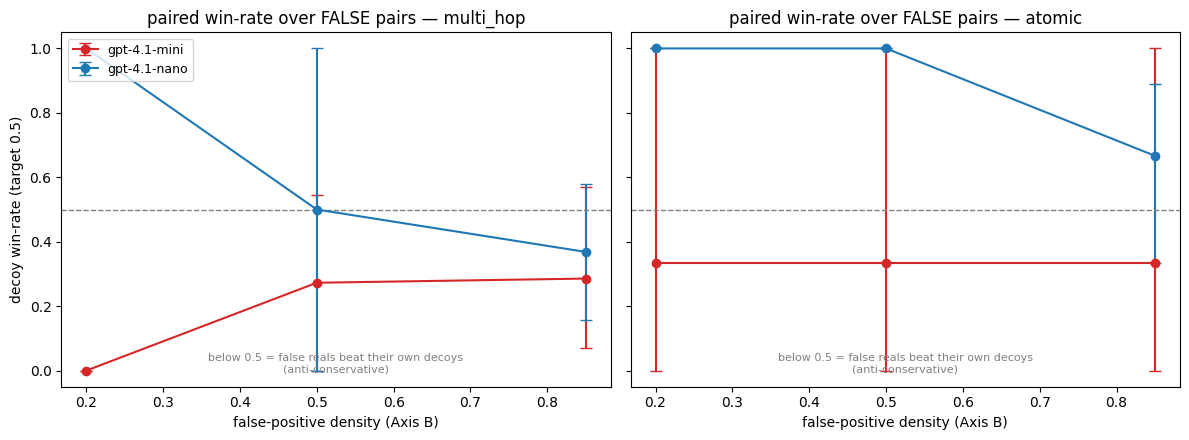

In [16]:
# ---- Figure 1: paired win-rate by density (the KEY readout) ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colors = {"openai/gpt-4.1-mini": "tab:red", "openai/gpt-4.1-nano": "tab:blue"}
dens_levels = [d for d in DENSITIES if d != "native"]
for ax, family in zip(axes, FAMILIES):
    for extractor in EXTRACTORS:
        xs, ys, los, his = [], [], [], []
        for d in dens_levels:
            c = next((c for c in cells if c["extractor"] == extractor and c["family"] == family
                      and c["density"] == d), None)
            if c is None or c["paired_win_rate"] is None:
                continue
            lo, hi = c["paired_win_rate_ci"]
            xs.append(d); ys.append(c["paired_win_rate"])
            los.append((c["paired_win_rate"] - lo) if lo is not None else 0.0)
            his.append((hi - c["paired_win_rate"]) if hi is not None else 0.0)
        if xs:
            ax.errorbar(xs, ys, yerr=[los, his], marker="o", capsize=4,
                        color=colors[extractor], label=extractor.split("/")[-1])
    ax.axhline(0.5, ls="--", color="gray", lw=1)
    ax.set_title(f"paired win-rate over FALSE pairs — {family}")
    ax.set_xlabel("false-positive density (Axis B)")
    ax.text(0.5, 0.04, "below 0.5 = false reals beat their own decoys\n(anti-conservative)",
            transform=ax.transAxes, ha="center", fontsize=8, color="gray")
axes[0].set_ylabel("decoy win-rate (target 0.5)")
axes[0].legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

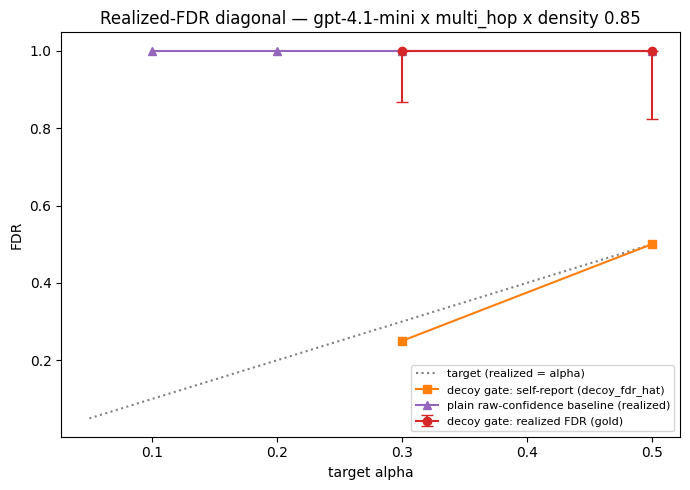

In [17]:
# ---- Figure 2: realized-FDR-vs-alpha diagonal for the headline cell ----
hc = next((c for c in cells if (c["extractor"], c["family"], c["density"]) == HEADLINE), None)
if hc is None:
    hc = next(c for c in cells if c["extractor"] == HEADLINE[0] and c["family"] == HEADLINE[1])
rows = hc["_diag"]["rows"]
def _v(x): return np.nan if x is None else x   # None (no admissions / no CI) -> nan, skipped by plot
al = [r["target_alpha"] for r in rows]
fig, ax = plt.subplots(figsize=(7, 5))
dfh = [_v(r["decoy_fdr_hat"]) for r in rows]
pln = [_v(r["plain_realized_fdr"]) for r in rows]
# the realized-FDR errorbar is drawn only where both the point and its bootstrap CI exist
ea_x, ea_y, ea_lo, ea_hi = [], [], [], []
for r in rows:
    if r["realized_fdr"] is not None and r["ci_low"] is not None and r["ci_high"] is not None:
        ea_x.append(r["target_alpha"]); ea_y.append(r["realized_fdr"])
        ea_lo.append(r["realized_fdr"] - r["ci_low"]); ea_hi.append(r["ci_high"] - r["realized_fdr"])
ax.plot(al, al, ls=":", color="gray", label="target (realized = alpha)")
if ea_x:
    ax.errorbar(ea_x, ea_y, yerr=[ea_lo, ea_hi], marker="o", capsize=4, color="tab:red",
                label="decoy gate: realized FDR (gold)")
ax.plot(al, dfh, marker="s", color="tab:orange", label="decoy gate: self-report (decoy_fdr_hat)")
ax.plot(al, pln, marker="^", color="tab:purple", label="plain raw-confidence baseline (realized)")
ax.set_xlabel("target alpha"); ax.set_ylabel("FDR")
ax.set_title(f"Realized-FDR diagonal — {HEADLINE[0].split('/')[-1]} x {HEADLINE[1]} x density {HEADLINE[2]}")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

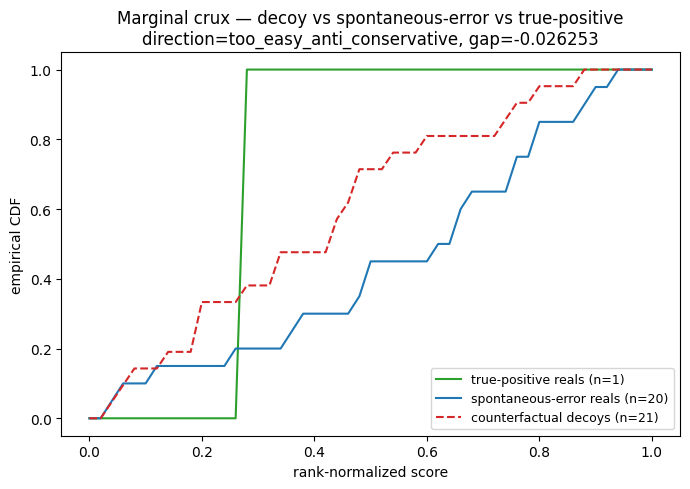

In [18]:
# ---- Figure 3: marginal score CDFs for the headline cell ----
cdf = hc["_marg"]["cdf"]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cdf["x"], cdf["cdf_truepos"], color="tab:green", label=f"true-positive reals (n={hc['_marg']['n_truepos']})")
ax.plot(cdf["x"], cdf["cdf_spont"], color="tab:blue", label=f"spontaneous-error reals (n={hc['_marg']['n_spont']})")
ax.plot(cdf["x"], cdf["cdf_decoy"], color="tab:red", ls="--", label=f"counterfactual decoys (n={hc['_marg']['n_decoy']})")
ax.set_xlabel("rank-normalized score"); ax.set_ylabel("empirical CDF")
ax.set_title(f"Marginal crux — decoy vs spontaneous-error vs true-positive\n"
             f"direction={hc['_marg']['marginal_direction']}, gap={hc['_marg']['tail_gap_mean_diff']}")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

In [19]:
# ---- Compare against the full-run reference ----
ref = data["reference"]
ev = ref["earned_vs_scoped_verdict"]
print("FULL-RUN REFERENCE")
print("=" * 70)
print("verdict :", ref["headline_verdict"])
print("headline:", (ev.get("headline") or ref["headline"])[:300])
print("\nmechanism:", (ev.get("mechanism") or "")[:300])
print("\nFull-run persistence matrix (powered; 200 docs, K=5 self-consistency):")
print(f"  {'extractor':>14} {'family':>10} {'density':>7} {'n_false':>7} "
      f"{'realized*':>9} {'paired_wr':>9} {'paired<0.5':>10} {'marginal_dir':>26}")
for c in ref["persistence_matrix_full_run"]:
    print(f"  {c['extractor'].split('/')[-1]:>14} {c['family']:>10} {c['density']:>7} "
          f"{c['n_false']:>7} {_f(c.get('realized_fdr_at_alpha_star'))} "
          f"{_f(c.get('paired_win_rate'))} {str(c.get('paired_fails')):>10} "
          f"{str(c.get('marginal_direction')):>26}")
print("\nNote: the demo subset (<=100 examples) reproduces the DIRECTION of the headline "
      "(competent multi_hop paired win-rate < 0.5) but with wide CIs; the reference above is the "
      "powered full-run result that yields the EARNED verdict.")

FULL-RUN REFERENCE
verdict : EARNED
headline: EARNED: the iter-3 paired/anti-conservative knockoff failure PERSISTS (and strengthens) with a COMPETENT extractor (openai/gpt-4.1-mini, mh_acc>=0.45, 3/3 powered multi_hop cells have paired-win-rate CI entirely <0.5 across >=3 densities). It manifests as a GOLD-based anti-conservative realized-FDR 

mechanism: the marginal 'cf decoys too easy' (tail gap_md<0) and the paired win-rate<0.5 are two views of the SAME self-favoring bias: the LLM scores its own extraction above a counterfactual decoy; this violates the knockoff null (decoy ~ null real) and makes the gate anti-conservative where the false-positiv

Full-run persistence matrix (powered; 200 docs, K=5 self-consistency):
       extractor     family density n_false realized* paired_wr paired<0.5               marginal_dir
    gpt-4.1-nano  multi_hop     0.2      45  0.176  0.387      False too_easy_anti_conservative
    gpt-4.1-nano  multi_hop     0.5     181   None  0.492      False t